    ##UK Food Price Intelligence: Detecting Volatility, Seasonality, and Market Vulnerabilities in Fresh Produce

In [2]:
import pandas as pd
df = pd.read_csv("./fruitvegprices.csv")

In [2]:
df.head()

,category,item,variety,date,price,unit
0,fruit,apples,bramleys_seedling,3/17/2025,1.35,kg
1,fruit,apples,coxs_orange_group,3/17/2025,1.26,kg
2,fruit,apples,braeburn,3/17/2025,1.17,kg
3,fruit,apples,gala,3/17/2025,1.24,kg
4,fruit,apples,other_mid_season,3/17/2025,1.37,kg


In [3]:
df.describe()

,price
count,15917.000000
mean,1.716899
std,2.124775
min,0.000000
25%,0.630000
50%,1.000000
75%,1.700000
max,20.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15917 entries, 0 to 15916
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  15917 non-null  object 
 1   item      15917 non-null  object 
 2   variety   15917 non-null  object 
 3   date      15917 non-null  object 
 4   price     15917 non-null  float64
 5   unit      15917 non-null  object 
dtypes: float64(1), object(5)
memory usage: 746.2+ KB


In [5]:
df.isnull().sum()

category    0
item        0
variety     0
date        0
price       0
unit        0
dtype: int64

In [6]:
negative_or_zero_prices = df[df['price'] <= 0]
negative_or_zero_prices
df = df[df['price'] > 0]


total_categories 4


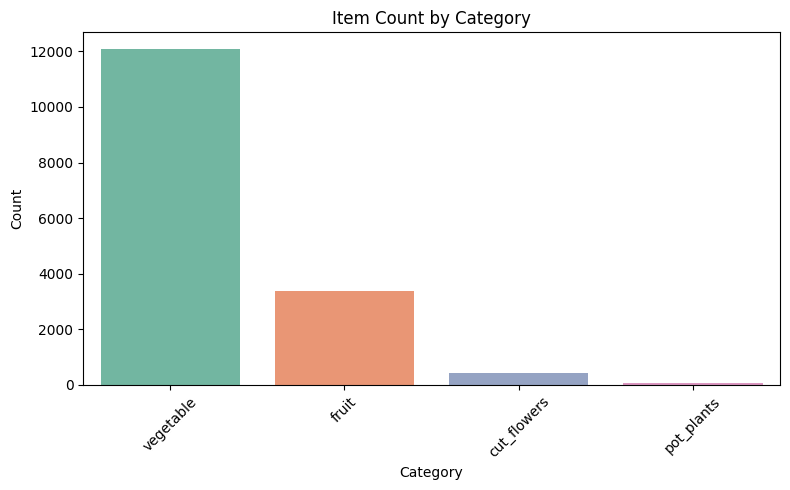

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

total_categories = df['category'].nunique()
print("total_categories",total_categories)
category_counts = df['category'].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(x=category_counts.index,  hue=category_counts.index,  y=category_counts.values, palette="Set2")
plt.title("Item Count by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


total unit :  5


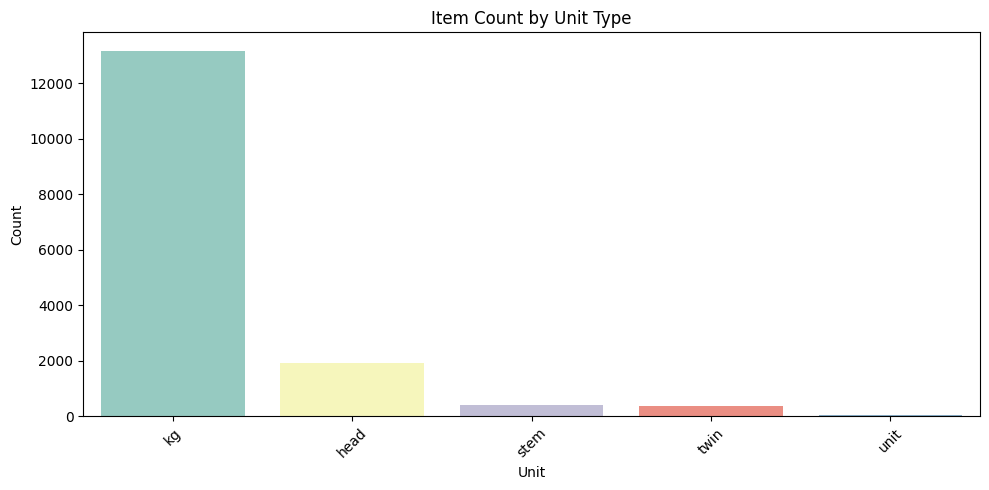

In [8]:
total_unit = df['unit'].nunique()
print("total unit : ",total_unit)
unit_counts = df['unit'].value_counts()


plt.figure(figsize=(10,5))
sns.barplot(x=unit_counts.index,     hue=unit_counts.index,  y=unit_counts.values, palette="Set3")
plt.title("Item Count by Unit Type")
plt.xlabel("Unit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
summary = df.groupby('category').agg(
    total_items=('price', 'count'),
    total_sales=('price', 'sum'),
    average_price=('price', 'mean'),
    max_price=('price', 'max'),
    min_price=('price', 'min'),
).sort_values(by='total_sales', ascending=False)

print(summary)


             total_items  total_sales  average_price  max_price  min_price
category                                                                  
vegetable          12080     18020.58       1.491770      20.00       0.12
fruit               3367      9128.10       2.711048      18.85       0.22
cut_flowers          420       114.27       0.272071       0.99       0.02
pot_plants            49        64.93       1.325102       2.13       0.55


In [10]:
# Dropping pot_plants
# Remove rows where category is 'pot_plants'
df = df[df['category'].str.strip().str.lower() != 'pot_plants']


Total Sales by Category:
 category
vegetable      18020.58
fruit           9128.10
cut_flowers      114.27
Name: price, dtype: float64


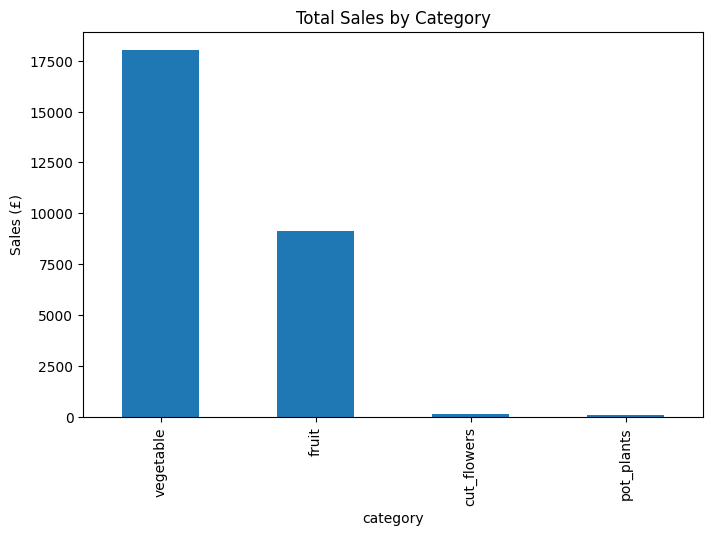

In [11]:
                            ##Total sales by Each category 
total_sales_by_category = df.groupby('category')['price'].sum().sort_values(ascending=False)
print("Total Sales by Category:\n", total_sales_by_category)
import matplotlib.pyplot as plt

summary['total_sales'].plot(kind='bar', title='Total Sales by Category', ylabel='Sales (£)', figsize=(8,5))
plt.show()


In [12]:
                              ##Average Price by Category
avg_price_by_category = df.groupby('category')['price'].mean().sort_values(ascending=False)
print("Average Price by Category:\n", avg_price_by_category)


Average Price by Category:
 category
fruit          2.711048
vegetable      1.491770
cut_flowers    0.272071
Name: price, dtype: float64


In [13]:
df.head()

,category,item,variety,date,price,unit
0,fruit,apples,bramleys_seedling,3/17/2025,1.35,kg
1,fruit,apples,coxs_orange_group,3/17/2025,1.26,kg
2,fruit,apples,braeburn,3/17/2025,1.17,kg
3,fruit,apples,gala,3/17/2025,1.24,kg
4,fruit,apples,other_mid_season,3/17/2025,1.37,kg


In [14]:
df.head()

,category,item,variety,date,price,unit
0,fruit,apples,bramleys_seedling,3/17/2025,1.35,kg
1,fruit,apples,coxs_orange_group,3/17/2025,1.26,kg
2,fruit,apples,braeburn,3/17/2025,1.17,kg
3,fruit,apples,gala,3/17/2025,1.24,kg
4,fruit,apples,other_mid_season,3/17/2025,1.37,kg


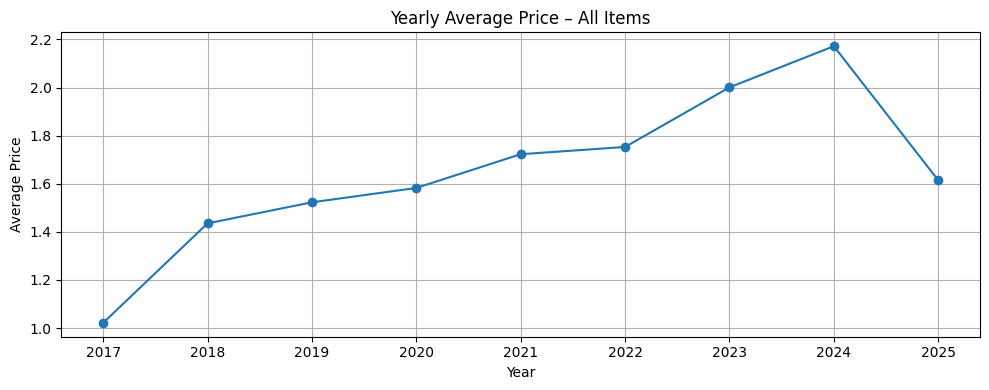

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# === 0. Make a copy & clean column names ===
df = df.copy()
df.columns = df.columns.str.strip()

# === 1. Ensure 'date' is a column, not just an index ===
if not 'date' in df.columns:
    # if your df.index is a DatetimeIndex, bring it back as a column
    if isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index().rename(columns={'index':'date'})
    else:
        raise KeyError("No 'date' column found and index is not datetime.")

# === 2. Convert and extract date parts ===
df['date'] = pd.to_datetime(df['date'])
df['year']      = df['date'].dt.year
df['month_num'] = df['date'].dt.month
df['month']     = df['date'].dt.strftime('%b')  # Jan, Feb, …

# === 3. (Optional) Drop unwanted category ===
df = df[df['category'].str.lower().str.strip() != 'pot_plants']

# === 4. Yearly average price — all items ===
yearly_avg_all = df.groupby('year')['price'].mean()

plt.figure(figsize=(10,4))
yearly_avg_all.plot(marker='o')
plt.title('Yearly Average Price – All Items')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

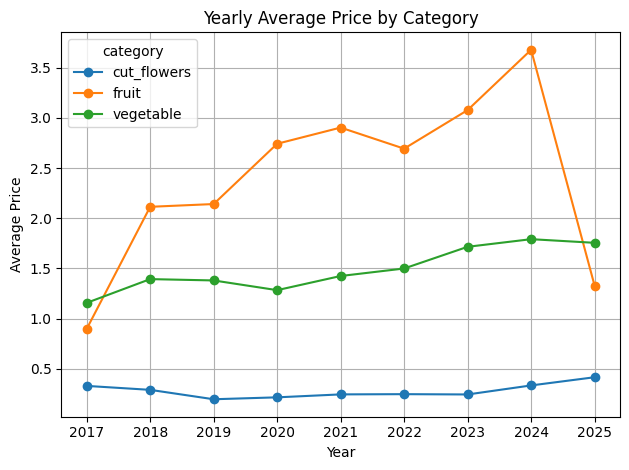

In [16]:


# === 5. Yearly average price — by category ===
yearly_avg_cat = df.groupby(['year','category'])['price'].mean().unstack()

plt.figure(figsize=(10,5))
yearly_avg_cat.plot(marker='o')
plt.title('Yearly Average Price by Category')
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.grid(True)
plt.tight_layout()
plt.show()


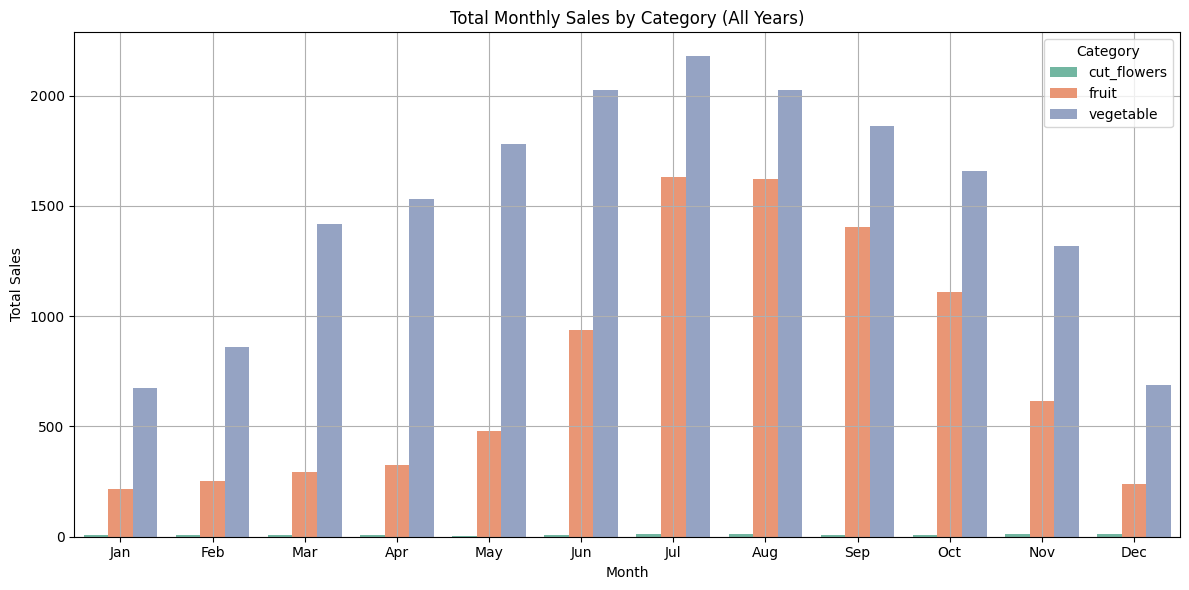

In [17]:

# === 6. Total monthly sales by category (all years) ===
monthly_sales = (
    df
    .groupby(['month_num','month','category'])['price']
    .sum()
    .reset_index()
    .sort_values('month_num')
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=monthly_sales,
    x='month', y='price',
    hue='category', palette='Set2',
    order=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)
plt.title('Total Monthly Sales by Category (All Years)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(title='Category')
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd

# Step 2: Group by category and item, then count the occurrences
item_counts = df.groupby(['category', 'item']).size().reset_index(name='count')

# Step 3: For each category, get the most common item (highest count)
most_common_items = item_counts.loc[item_counts.groupby('category')['count'].idxmax()]

# Step 4: Display the result
print("Most Common Items by Category")

print(most_common_items)


Most Common Items by Category
       category      item  count
8   cut_flowers    tulips    141
9         fruit    apples   1789
19   pot_plants  cyclamen     29
26    vegetable   cabbage   1669
